# NLP Review Analysis

This notebook analyzes review text, sentiment, language, and uses an LLM to summarize the findings.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

# Pull a representative sample of reviews with their listing scores
# Using 10,000 reviews for speed — stratified across listings
reviews_sample = con.execute("""
    SELECT 
        r.review_id,
        r.listing_id,
        r.comment_length,
        f.review_scores_rating,
        f.review_scores_cleanliness,
        f.review_scores_location,
        f.review_scores_value,
        f.price
    FROM fact_reviews r
    JOIN fact_listing_performance f ON r.listing_id = f.listing_id
    WHERE f.review_scores_rating IS NOT NULL
    USING SAMPLE 10000
""").df()

print(f"Sample shape: {reviews_sample.shape}")
print(reviews_sample.head(3))

Sample shape: (10000, 8)
             review_id           listing_id  comment_length  \
0  1470274883447357948  1430606282633208193             180   
1            284063547              5494667             855   
2            737886141             34797717             195   

   review_scores_rating  review_scores_cleanliness  review_scores_location  \
0                  4.96                       4.90                    4.76   
1                  4.94                       4.89                    4.98   
2                  4.42                       4.50                    4.61   

   review_scores_value   price  
0                 4.71  222.75  
1                 4.85  885.00  
2                 4.27  251.82  


# NLP Review Analysis

This notebook analyses review text, sentiment, language, and uses an LLM to synthesize the findings.

In [2]:
review_ids = reviews_sample['review_id'].tolist()
placeholders = ','.join(map(str, review_ids))

review_text = con.execute(f"""
    SELECT id AS review_id, comments
    FROM stg_reviews
    WHERE id IN ({placeholders})
""").df()

reviews_df = reviews_sample.merge(review_text, on='review_id')
print(f"Reviews with text: {len(reviews_df)}")
print(f"Sample review: {reviews_df['comments'].iloc[0][:200]}")

Reviews with text: 10000
Sample review: Great property would thoroughly recommend. The host was absolutely fabulous going over and above what is required.<br/>Thank you so much for all your help.<br/>Real personal touch.


In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

print("Running VADER sentiment analysis on 10,000 reviews...")
sentiments = []
for text in reviews_df['comments']:
    if pd.isna(text) or text == '':
        sentiments.append({'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0})
    else:
        # Strip HTML tags first
        clean = str(text).replace('<br/>', ' ').replace('<br>', ' ')
        sentiments.append(analyzer.polarity_scores(clean))

sentiment_df = pd.DataFrame(sentiments)
reviews_df = pd.concat([reviews_df.reset_index(drop=True), sentiment_df], axis=1)

print(f"Done. Sentiment distribution:")
print(reviews_df['compound'].describe())
print(f"\nPositive (compound > 0.05): {(reviews_df['compound'] > 0.05).sum()} ({(reviews_df['compound'] > 0.05).mean()*100:.1f}%)")
print(f"Neutral (-0.05 to 0.05): {((reviews_df['compound'] >= -0.05) & (reviews_df['compound'] <= 0.05)).sum()}")
print(f"Negative (compound < -0.05): {(reviews_df['compound'] < -0.05).sum()} ({(reviews_df['compound'] < -0.05).mean()*100:.1f}%)")

Running VADER sentiment analysis on 10,000 reviews...
Done. Sentiment distribution:
count    10000.000000
mean         0.499071
std          0.506528
min         -0.996600
25%          0.000000
50%          0.724300
75%          0.936000
max          0.998200
Name: compound, dtype: float64

Positive (compound > 0.05): 6796 (68.0%)
Neutral (-0.05 to 0.05): 2362
Negative (compound < -0.05): 842 (8.4%)


In [4]:
# Sample the zero-compound reviews to check if they're non-English
zero_sentiment = reviews_df[reviews_df['compound'] == 0.0]['comments'].head(10)
for i, text in enumerate(zero_sentiment):
    print(f"--- Review {i+1} ---")
    print(str(text)[:200])
    print()

--- Review 1 ---
Bon accueil<br/>Bien placé

--- Review 2 ---
Acogedor apartamento en una zona atractiva de Barcelona, cerca de servicios, el MAR y lugares de ocio y restauracion.  Al llegar alguna de nosotras dijo "está mejor que en  las fotos". Estancia agrada

--- Review 3 ---
הדירה פשוט מקסימה, לא יכולנו לבקש מיקום מושלם יותר מזה, מצד אחד נמצא בלב העיר, מרחק הליכה של פחות מעשר דקות מכל הדברים החשובים בעיר, מצד שני שכונה שקטה ונקיה, יש מינימרקט בכל פינה ובתי קפה חמודים.<br/

--- Review 4 ---
Appartement très bien placé en plein centre ville. Très bien équipé.  L'Ascenseur est le bienvenu. Calme.

--- Review 5 ---
.

--- Review 6 ---
Appartement sympa et parfait pour 5 personnes. Petit balcon très agréable. <br/>Très bon accueil.<br/>Quartier jeune et dynamique avec accès direct au métro. Je recommande!

--- Review 7 ---
Szuper elhelyezkedés, szuper szállás. A kommunikáció nehézkes volt, megadott kapcsolattartó egy üzenetre sem reagált így kicsit bizonytalanul indultunk neki. Végül m

In [5]:
from langdetect import detect, LangDetectException

def detect_language(text):
    try:
        clean = str(text).replace('<br/>', ' ').replace('<br>', ' ').strip()
        if len(clean) < 10:
            return 'unknown'
        return detect(clean)
    except LangDetectException:
        return 'unknown'

print("Detecting languages (may take ~30 seconds)...")
reviews_df['language'] = reviews_df['comments'].apply(detect_language)

lang_counts = reviews_df['language'].value_counts()
print(f"\nTop 15 languages detected:")
print(lang_counts.head(15))
print(f"\nEnglish reviews: {(reviews_df['language'] == 'en').sum()} ({(reviews_df['language'] == 'en').mean()*100:.1f}%)")
print(f"Non-English: {(reviews_df['language'] != 'en').sum()} ({(reviews_df['language'] != 'en').mean()*100:.1f}%)")

Detecting languages (may take ~30 seconds)...

Top 15 languages detected:
language
en         5885
es         1212
fr         1088
de          429
it          299
unknown     233
pt          153
nl          106
ko           92
zh-cn        80
ru           70
pl           49
tr           39
sv           38
ro           36
Name: count, dtype: int64

English reviews: 5885 (58.9%)
Non-English: 4115 (41.1%)


English reviews for analysis: 5885

Correlation with VADER compound sentiment score:
compound                     1.000
review_scores_rating         0.245
review_scores_value          0.236
review_scores_cleanliness    0.209
review_scores_location       0.117
comment_length               0.071
Name: compound, dtype: float64


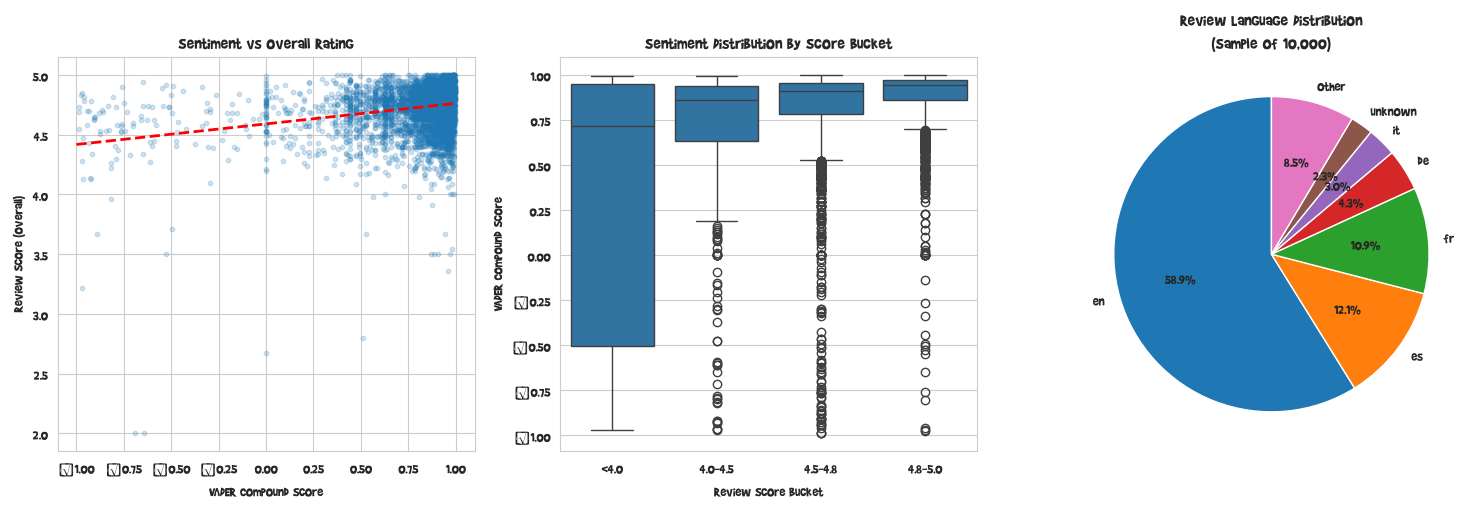


Median sentiment by score bucket:
score_bucket
<4.0       0.715
4.0-4.5    0.860
4.5-4.8    0.908
4.8-5.0    0.941
Name: compound, dtype: float64


In [6]:
# Filter to English only for VADER analysis
english_reviews = reviews_df[reviews_df['language'] == 'en'].copy()
print(f"English reviews for analysis: {len(english_reviews)}")

# Correlation: VADER compound score vs numerical review dimensions
corr_cols = ['compound', 'review_scores_rating', 'review_scores_cleanliness',
             'review_scores_location', 'review_scores_value', 'comment_length']
corr_matrix = english_reviews[corr_cols].corr()

print("\nCorrelation with VADER compound sentiment score:")
print(corr_matrix['compound'].sort_values(ascending=False).round(3))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Sentiment vs overall rating
axes[0].scatter(english_reviews['compound'],
                english_reviews['review_scores_rating'],
                alpha=0.2, s=10)
axes[0].set_xlabel("VADER Compound Score")
axes[0].set_ylabel("Review Score (Overall)")
axes[0].set_title("Sentiment vs Overall Rating")

# Add trend line
z = np.polyfit(english_reviews['compound'],
               english_reviews['review_scores_rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(-1, 1, 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2)

# 2. Sentiment distribution by score bucket
english_reviews['score_bucket'] = pd.cut(
    english_reviews['review_scores_rating'],
    bins=[0, 4.0, 4.5, 4.8, 5.01],
    labels=['<4.0', '4.0-4.5', '4.5-4.8', '4.8-5.0']
)
sns.boxplot(data=english_reviews, x='score_bucket',
            y='compound', ax=axes[1])
axes[1].set_title("Sentiment Distribution by Score Bucket")
axes[1].set_xlabel("Review Score Bucket")
axes[1].set_ylabel("VADER Compound Score")

# 3. Language mix pie chart
lang_top = lang_counts.head(6)
lang_other = pd.Series({'other': lang_counts[6:].sum()})
lang_plot = pd.concat([lang_top, lang_other])
axes[2].pie(lang_plot.values, labels=lang_plot.index,
            autopct='%1.1f%%', startangle=90)
axes[2].set_title("Review Language Distribution\n(Sample of 10,000)")

plt.tight_layout()
plt.savefig("../reports/figures/sentiment_analysis.png", dpi=150)
plt.show()

print("\nMedian sentiment by score bucket:")
print(english_reviews.groupby('score_bucket', observed=True)['compound'].median().round(3))

In [8]:
from groq import Groq
from dotenv import load_dotenv
import os

load_dotenv("../.env")  # loads from project root
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

test = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Say 'API connected' and nothing else."}],
    max_tokens=10
)
print(test.choices[0].message.content)

API connected


In [ ]:
# Compile actual findings from our analysis into a structured context
findings_context = """
BARCELONA AIRBNB MARKET ANALYSIS — KEY FINDINGS SUMMARY
Data: Inside Airbnb Barcelona snapshot, June 2026
Total listings: 15,293 | Active listings: 9,666 | Unique hosts: 4,595

=== MARKET STRUCTURE ===
- Top 500 hosts (10.9% of all hosts) control 61.1% of all listings
- Single largest operator controls 588 listings (3.8% of entire market)
- 65% of hosts operate just 1 listing, but these control only 19.5% of inventory
- Only 890 unique verified HUTB license numbers found across 15,293 listings
- 3,676 listings (24%) declare exemption status rather than holding formal license
- 3,043 listings (19.9%) have no license information at all

=== PRICING ===
- Median nightly price (active listings): €213.68
- Mean nightly price (active listings): €234.33
- Entire home/apt median: €240.10 vs Private room median: €92.00 (161% premium)
- Price distribution heavily right-skewed (skewness 2.53-8.97 by segment)
- Neighbourhood pricing tiers identified:
  * Premium: Eixample (€257.50 median) — standalone tier, significantly different from all others
  * Upper-mid: Sant Martí (€230), Gràcia (€217), Sarrià-Sant Gervasi (€196)
  * Mid: Les Corts (€193), Sants-Montjuïc (€201), Horta-Guinardó (€165)
  * Budget: Nou Barris (€80), Sant Andreu (€92), Ciutat Vella (€125)

=== DEMAND & SEASONALITY ===
- 36.8% of listings show zero occupancy in trailing 365 days
- Seasonality: peak demand in May (historical) and July (forward bookings)
- Winter trough: Dec-Jan (~35% below peak)
- Weekend vs weekday availability: statistically significant but practically negligible (0.39pp difference)

=== HOST QUALITY ===
- Superhosts: 25.9% of listings, median rating 4.86 vs non-superhost 4.63
- Superhosts receive 3x more reviews at essentially same price point
- Price shows near-zero correlation with rating (r=0.073)

=== REGULATORY CONTEXT ===
- All ~10,101 Barcelona HUT tourist licenses expire November 2028, will not be renewed
- No new licenses issued since 2014 moratorium
- Constitutional Court upheld phase-out March 2025
- Operating without license carries fines up to €600,000
- Barcelona rents have risen 62% over past decade, driving regulatory action

=== ML MODEL (Price Prediction) ===
- XGBoost R²=0.857, MAE=€50.36 on active listings
- Top price drivers: minimum_nights (proxy for rental type), room_type, accommodates
- Eixample is only neighbourhood with meaningful standalone price premium in model
- Model underpredicts in Nou Barris (-15.5% mean error) and for shared rooms (-14.1%)

=== SENTIMENT ANALYSIS ===
- 58.9% of reviews in English; remainder in Spanish (12.1%), French (10.9%), German (4.3%), other
- VADER sentiment correlates moderately with overall rating (r=0.245) and value (r=0.236)
- Location scores show weakest sentiment correlation (r=0.117) — described objectively not emotionally
"""

def generate_market_briefing(findings, audience="executive"):
    """Generate a structured market intelligence briefing using LLM."""
    
    if audience == "executive":
        persona = "a senior market intelligence analyst writing for C-suite executives and investors"
        format_instruction = """Write a structured market intelligence briefing with these sections:
        1. MARKET SNAPSHOT (3-4 sentences, headline numbers only)
        2. KEY OPPORTUNITY (2-3 sentences, biggest actionable insight)
        3. KEY RISK (2-3 sentences, biggest threat/concern)
        4. REGULATORY ALERT (2-3 sentences, 2028 phase-out implications)
        5. STRATEGIC RECOMMENDATION (3-4 sentences, specific and actionable)
        Keep total length to 400-500 words. Be specific, cite actual numbers, no vague statements."""
    
    elif audience == "host":
        persona = "a data-driven Airbnb hosting consultant writing for individual property hosts"
        format_instruction = """Write a practical hosting guide with these sections:
        1. MARKET POSITIONING (How to position your listing competitively)
        2. PRICING STRATEGY (Specific pricing guidance with numbers)
        3. QUALITY SIGNAL (What drives bookings beyond price)
        4. REGULATORY WARNING (What hosts need to know about 2028)
        5. TOP 3 ACTION ITEMS (Specific, numbered, immediately actionable)
        Keep total length to 400-500 words. Be direct and practical."""

    prompt = f"""You are {persona}.

Based on the following data analysis findings from a rigorous study of Barcelona's Airbnb market (June 2026 data, 15,293 listings, statistical hypothesis testing, machine learning price modeling, and NLP sentiment analysis):

{findings}

{format_instruction}

Important: Only reference findings explicitly stated above. Do not invent statistics or add external information not present in the findings."""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1000,
        temperature=0.3  # lower temperature = more factual, less hallucination
    )
    return response.choices[0].message.content

print("Generating executive briefing...")
executive_briefing = generate_market_briefing(findings_context, audience="executive")
print("\n" + "="*70)
print("EXECUTIVE MARKET INTELLIGENCE BRIEFING")
print("="*70)
print(executive_briefing)

Generating executive briefing...

EXECUTIVE MARKET INTELLIGENCE BRIEFING
**1. MARKET SNAPSHOT**
The Barcelona Airbnb market consists of 15,293 listings, with 9,666 active listings and 4,595 unique hosts. The median nightly price for active listings is €213.68, with a mean nightly price of €234.33. The top 500 hosts control 61.1% of all listings, while 65% of hosts operate just one listing, controlling only 19.5% of the inventory. The market is characterized by a heavily right-skewed price distribution, with a skewness of 2.53-8.97 by segment.

**2. KEY OPPORTUNITY**
The largest opportunity in the Barcelona Airbnb market lies in the premium neighborhood of Eixample, which has a median price of €257.50 and is significantly different from all other neighborhoods. With the top 500 hosts controlling 61.1% of listings, there is a chance for strategic partnerships or acquisitions to gain market share. Additionally, the fact that 36.8% of listings show zero occupancy in the trailing 365 days s

In [11]:
print("Generating host briefing...")
host_briefing = generate_market_briefing(findings_context, audience="host")
print("\n" + "="*70)
print("HOST INTELLIGENCE BRIEFING")
print("="*70)
print(host_briefing)

Generating host briefing...

HOST INTELLIGENCE BRIEFING
As a Barcelona Airbnb host, understanding the local market is crucial to success. Here's a practical guide to help you navigate the competitive landscape.

### 1. MARKET POSITIONING
To position your listing competitively, consider the neighbourhood pricing tiers. If your listing is in Eixample, you're in a premium tier with a median price of €257.50. For other areas like Sant Martí, Gràcia, or Sarrià-Sant Gervasi, prices are lower but still in the upper-mid range (€230, €217, and €196 respectively). Budget-friendly areas include Nou Barris and Sant Andreu, with medians of €80 and €92.

### 2. PRICING STRATEGY
The median nightly price for active listings is €213.68, with a mean of €234.33. Entire homes/apartments command a 161% premium over private rooms, with medians of €240.10 and €92.00 respectively. Consider these benchmarks when setting your prices. Also, note that price shows near-zero correlation with rating (r=0.073), so fo

In [12]:
import datetime

output = f"""BARCELONA AIRBNB MARKET INTELLIGENCE BRIEFINGS
Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}
Model: llama-3.3-70b-versatile (Groq API)
Data source: Inside Airbnb Barcelona, June 2026 snapshot
Analysis: Expernetic Data Engineering Assignment

{'='*70}
EXECUTIVE BRIEFING
{'='*70}
{executive_briefing}

{'='*70}
HOST BRIEFING
{'='*70}
{host_briefing}
"""

with open("../reports/market_intelligence_briefings.txt", "w", encoding="utf-8") as f:
    f.write(output)

print("Saved to reports/market_intelligence_briefings.txt")

Saved to reports/market_intelligence_briefings.txt
